# BFM Model Training by Environment

This notebook trains **3 separate models** for different environments:
1. **nofoil** - Indoor without foil
2. **foil** - Indoor with foil
3. **open** - Open environment

Each model is trained and tested independently to show environment-specific performance.

**Training Set:** Abel, Collin, Ivan  
**Test Set:** Kenny, Matthew

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from scipy.ndimage import median_filter
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, Input

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.16.2
GPU available: True


## 1. Configuration

In [2]:
# Configuration
DATA_FILE = "Cleaned and combined/bfm_data.csv"

# TRAIN 3 ENVIRONMENTS SEPARATELY
ENVIRONMENTS = ['nofoil', 'foil', 'open']

# Windowing parameters
WINDOW_SIZE = 50
WINDOW_STRIDE = 10

# Preprocessing parameters
MEDIAN_FILTER_SIZE = 9
ROLLING_MEAN_WINDOW = 20
ROLLING_STD_WINDOW = 101
PCA_COMPONENTS = 5

# Training parameters
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Train/Test split by person
TRAIN_SUBJECTS = ['abel', 'collin', 'ivan', 'kenny']
TEST_SUBJECTS = [ 'matthew']

print(f"Training {len(ENVIRONMENTS)} environments: {ENVIRONMENTS}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Test subjects: {TEST_SUBJECTS}")

Training 3 environments: ['nofoil', 'foil', 'open']
Train subjects: ['abel', 'collin', 'ivan', 'kenny']
Test subjects: ['matthew']


## 2. Helper Functions

In [3]:
def apply_median_filter(df, cols, window_size=9):
    """Apply median filter per session to remove outliers."""
    df_filtered = df.copy()
    
    for session_id in df['session_id'].unique():
        mask = df['session_id'] == session_id
        session_data = df.loc[mask, cols].values
        filtered_data = median_filter(session_data, size=(window_size, 1), mode='nearest')
        df_filtered.loc[mask, cols] = filtered_data
    
    return df_filtered

def apply_rolling_z_score(df, cols, mean_window=20, std_window=101):
    """Apply rolling Z-score normalization per session."""
    df_normalized = df.copy()
    
    for session_id in df['session_id'].unique():
        mask = df['session_id'] == session_id
        session_data = df.loc[mask, cols]
        
        rolling_mean = session_data.rolling(window=mean_window, min_periods=1).mean()
        centered = session_data - rolling_mean
        rolling_std = centered.rolling(window=std_window, min_periods=std_window).std()
        normalized = centered / (rolling_std + 1e-8)
        
        df_normalized.loc[mask, cols] = normalized
    
    df_normalized = df_normalized.dropna(subset=cols)
    return df_normalized

def create_sliding_windows(df, pca_cols, window_size=50, stride=10):
    """Create sliding windows from time-series data."""
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['activity'])
    
    X_windows = []
    y_windows = []
    
    for session_id in df['session_id'].unique():
        session_df = df[df['session_id'] == session_id].sort_values('timestamp')
        features = session_df[pca_cols].values
        labels = session_df['label_encoded'].values
        
        for i in range(0, len(features) - window_size + 1, stride):
            window = features[i:i + window_size]
            label = labels[i + window_size - 1]
            X_windows.append(window)
            y_windows.append(label)
    
    return np.array(X_windows), np.array(y_windows), le

def build_temporal_cnn(window_size, n_features, num_classes):
    """Build a 1D CNN for temporal window classification."""
    input_tensor = Input(shape=(window_size, n_features))
    x = layers.Permute((2, 1))(input_tensor)
    
    x = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    
    output_tensor = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=input_tensor, outputs=output_tensor)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("[INFO] Helper functions defined")

[INFO] Helper functions defined


## 3. Load Full Dataset

In [4]:
print("[INFO] Loading combined BFM data...")
df_full = pd.read_csv(DATA_FILE)

# Get feature columns
mag_cols = sorted([c for c in df_full.columns if 'Ratio_Mag' in c])
phase_cols = sorted([c for c in df_full.columns if 'Ratio_Phase' in c])
feature_cols = mag_cols + phase_cols

print(f"[INFO] Total samples: {len(df_full)}")
print(f"[INFO] Features: {len(feature_cols)} ({len(mag_cols)} Mag + {len(phase_cols)} Phase)")
print(f"[INFO] Environments available: {df_full['environment'].unique()}")
print(f"[INFO] Subjects available: {sorted(df_full['subject'].unique())}")
print(f"[INFO] Activities: {sorted(df_full['activity'].unique())}")

[INFO] Loading combined BFM data...
[INFO] Total samples: 143214
[INFO] Features: 468 (234 Mag + 234 Phase)
[INFO] Environments available: ['nofoil' 'foil' 'open']
[INFO] Subjects available: ['abel', 'collin', 'ivan', 'kenny', 'matthew']
[INFO] Activities: ['standing', 'walking']


## 4. Train and Test Each Environment

This section trains 3 separate models, one for each environment.

In [5]:
# Store results for all environments
all_results = {}
all_histories = {}
all_models = {}

for env_idx, environment in enumerate(ENVIRONMENTS):
    print("\n" + "="*80)
    print(f"ENVIRONMENT {env_idx+1}/{len(ENVIRONMENTS)}: {environment.upper()}")
    print("="*80 + "\n")
    
    # ========== 1. Filter by environment ==========
    print(f"[{environment}] Step 1: Filtering data...")
    df = df_full[df_full['environment'] == environment].copy()
    print(f"  Found {len(df)} samples for '{environment}'")
    print(f"  Sessions: {df['session_id'].nunique()}")
    
    if len(df) == 0:
        print(f"  WARNING: No data for environment '{environment}', skipping...")
        continue
    
    # ========== 2. Apply median filter ==========
    print(f"[{environment}] Step 2: Applying median filter...")
    df = apply_median_filter(df, feature_cols, MEDIAN_FILTER_SIZE)
    
    # ========== 3. Split train/test by person ==========
    print(f"[{environment}] Step 3: Splitting by person...")
    df_train = df[df['subject'].isin(TRAIN_SUBJECTS)].copy()
    df_test = df[df['subject'].isin(TEST_SUBJECTS)].copy()
    
    print(f"  Train: {len(df_train)} samples from {TRAIN_SUBJECTS}")
    print(f"  Test: {len(df_test)} samples from {TEST_SUBJECTS}")
    
    if len(df_train) == 0 or len(df_test) == 0:
        print(f"  WARNING: Insufficient data for train/test split, skipping...")
        continue
    
    # ========== 4. Apply PCA ==========
    print(f"[{environment}] Step 4: Applying PCA ({PCA_COMPONENTS} components)...")
    pca = PCA(n_components=PCA_COMPONENTS)
    pca_train = pca.fit_transform(df_train[feature_cols])
    pca_test = pca.transform(df_test[feature_cols])
    
    pca_cols = [f'pca{i}' for i in range(PCA_COMPONENTS)]
    df_train[pca_cols] = pca_train
    df_test[pca_cols] = pca_test
    
    df_train.drop(feature_cols, axis=1, inplace=True)
    df_test.drop(feature_cols, axis=1, inplace=True)
    
    print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
    
    # ========== 5. Apply rolling Z-score ==========
    print(f"[{environment}] Step 5: Applying rolling Z-score normalization...")
    df_train = apply_rolling_z_score(df_train, pca_cols, ROLLING_MEAN_WINDOW, ROLLING_STD_WINDOW)
    df_test = apply_rolling_z_score(df_test, pca_cols, ROLLING_MEAN_WINDOW, ROLLING_STD_WINDOW)
    
    print(f"  Train after normalization: {len(df_train)} samples")
    print(f"  Test after normalization: {len(df_test)} samples")
    
    # ========== 6. Create sliding windows ==========
    print(f"[{environment}] Step 6: Creating sliding windows...")
    X_train, y_train, le = create_sliding_windows(df_train, pca_cols, WINDOW_SIZE, WINDOW_STRIDE)
    X_test, y_test, _ = create_sliding_windows(df_test, pca_cols, WINDOW_SIZE, WINDOW_STRIDE)
    
    print(f"  Train windows: {X_train.shape}")
    print(f"  Test windows: {X_test.shape}")
    print(f"  Classes: {le.classes_}")
    
    # ========== 7. Build model ==========
    print(f"[{environment}] Step 7: Building model...")
    model = build_temporal_cnn(WINDOW_SIZE, PCA_COMPONENTS, len(le.classes_))
    
    # ========== 8. Train model ==========
    print(f"[{environment}] Step 8: Training model...\n")
    
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    
    train_dataset = train_dataset.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    cb = [
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )
    ]
    
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=EPOCHS,
        callbacks=cb,
        verbose=2  # One line per epoch
    )
    
    # ========== 9. Evaluate model ==========
    print(f"\n[{environment}] Step 9: Evaluating model...")
    loss, acc = model.evaluate(test_dataset, verbose=0)
    
    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4, output_dict=True)
    
    # Store results
    all_results[environment] = {
        'accuracy': acc,
        'loss': loss,
        'confusion_matrix': cm,
        'classification_report': report,
        'label_encoder': le,
        'y_true': y_test,
        'y_pred': y_pred
    }
    all_histories[environment] = history.history
    all_models[environment] = model
    
    # Save model
    model_path = f'best_bfm_model_{environment}.keras'
    model.save(model_path)
    
    print(f"\n{'='*60}")
    print(f"RESULTS FOR {environment.upper()}")
    print("="*60)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"Model saved to: {model_path}")
    print("="*60)

print("\n" + "="*80)
print("ALL ENVIRONMENTS TRAINING COMPLETE")
print("="*80)


ENVIRONMENT 1/3: NOFOIL

[nofoil] Step 1: Filtering data...
  Found 47540 samples for 'nofoil'
  Sessions: 50
[nofoil] Step 2: Applying median filter...
[nofoil] Step 3: Splitting by person...
  Train: 37933 samples from ['abel', 'collin', 'ivan', 'kenny']
  Test: 9607 samples from ['matthew']
[nofoil] Step 4: Applying PCA (5 components)...
  Explained variance: 0.8364
[nofoil] Step 5: Applying rolling Z-score normalization...
  Train after normalization: 33933 samples
  Test after normalization: 8607 samples
[nofoil] Step 6: Creating sliding windows...
  Train windows: (3215, 50, 5)
  Test windows: (816, 50, 5)
  Classes: ['standing' 'walking']
[nofoil] Step 7: Building model...


2025-10-28 08:05:15.206435: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-10-28 08:05:15.206487: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-10-28 08:05:15.206498: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2025-10-28 08:05:15.206548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-28 08:05:15.206567: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


[nofoil] Step 8: Training model...

Epoch 1/50


2025-10-28 08:05:15.820436: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


51/51 - 2s - 44ms/step - accuracy: 0.5002 - loss: 1.1460 - val_accuracy: 0.5196 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/50
51/51 - 1s - 13ms/step - accuracy: 0.5076 - loss: 1.1368 - val_accuracy: 0.5135 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 3/50
51/51 - 1s - 13ms/step - accuracy: 0.5157 - loss: 1.0779 - val_accuracy: 0.5233 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 4/50
51/51 - 1s - 13ms/step - accuracy: 0.5045 - loss: 0.9947 - val_accuracy: 0.5723 - val_loss: 0.6799 - learning_rate: 0.0010
Epoch 5/50
51/51 - 1s - 13ms/step - accuracy: 0.5166 - loss: 0.8880 - val_accuracy: 0.5968 - val_loss: 0.6718 - learning_rate: 0.0010
Epoch 6/50
51/51 - 1s - 13ms/step - accuracy: 0.5412 - loss: 0.8076 - val_accuracy: 0.6115 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 7/50
51/51 - 1s - 13ms/step - accuracy: 0.5459 - loss: 0.7566 - val_accuracy: 0.6213 - val_loss: 0.6538 - learning_rate: 0.0010
Epoch 8/50
51/51 - 1s - 13ms/step - accuracy: 0.5838 - loss: 0.6958 - val

## 5. Summary Results Comparison

In [6]:
print("\n" + "="*80)
print("SUMMARY: COMPARISON ACROSS ALL ENVIRONMENTS")
print("="*80 + "\n")

# Create comparison table
summary_data = []
for env in ENVIRONMENTS:
    if env in all_results:
        result = all_results[env]
        summary_data.append({
            'Environment': env,
            'Accuracy': f"{result['accuracy']:.4f}",
            'Loss': f"{result['loss']:.4f}",
            'Standing Precision': f"{result['classification_report']['standing']['precision']:.4f}",
            'Standing Recall': f"{result['classification_report']['standing']['recall']:.4f}",
            'Walking Precision': f"{result['classification_report']['walking']['precision']:.4f}",
            'Walking Recall': f"{result['classification_report']['walking']['recall']:.4f}"
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*80)


SUMMARY: COMPARISON ACROSS ALL ENVIRONMENTS

Environment Accuracy   Loss Standing Precision Standing Recall Walking Precision Walking Recall
     nofoil   0.8002 0.6248             0.8311          0.7512            0.7751         0.8488
       foil   0.6116 0.7017             0.5709          0.7098            0.6692         0.5239
       open   0.8777 0.3015             0.8880          0.8633            0.8680         0.8920



## 6. Visualize Training History for All Environments

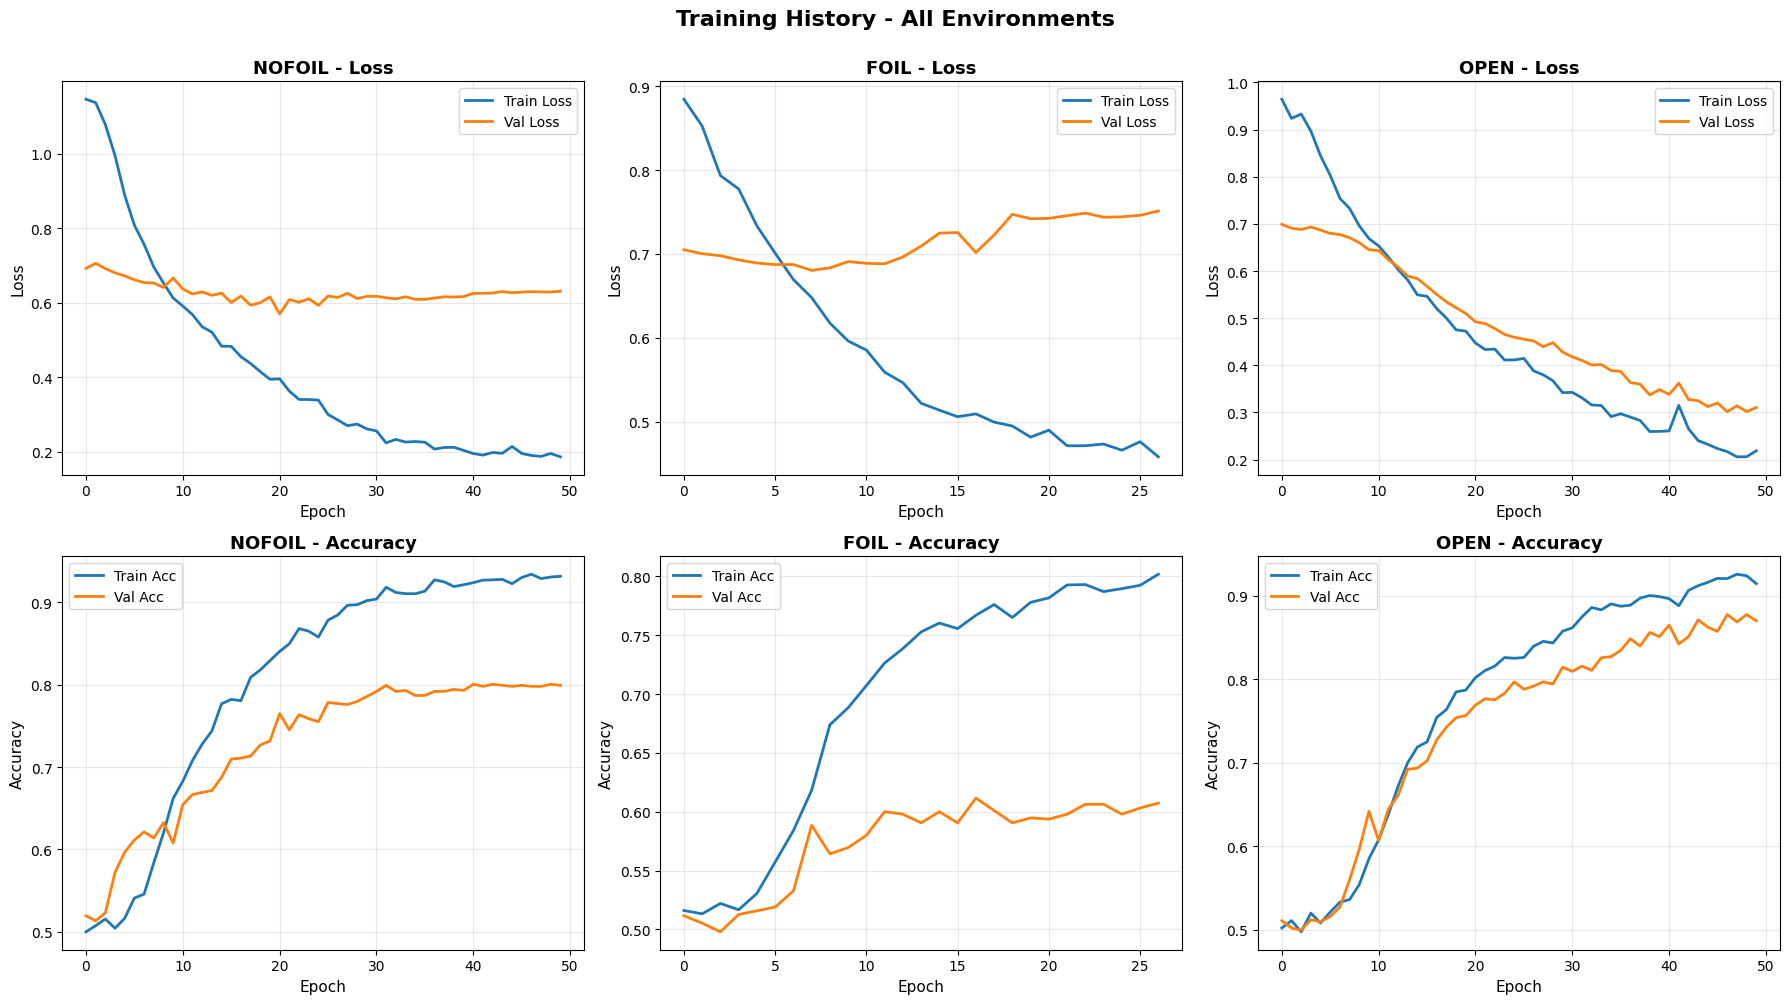

[INFO] Training history plot saved to 'bfm_all_environments_history.png'


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, env in enumerate(ENVIRONMENTS):
    if env not in all_histories:
        continue
        
    history = all_histories[env]
    
    # Loss plot
    ax = axes[0, idx]
    ax.plot(history['loss'], label='Train Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'{env.upper()} - Loss', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax = axes[1, idx]
    ax.plot(history['accuracy'], label='Train Acc', linewidth=2)
    ax.plot(history['val_accuracy'], label='Val Acc', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{env.upper()} - Accuracy', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History - All Environments', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('bfm_all_environments_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("[INFO] Training history plot saved to 'bfm_all_environments_history.png'")

## 7. Confusion Matrices for All Environments

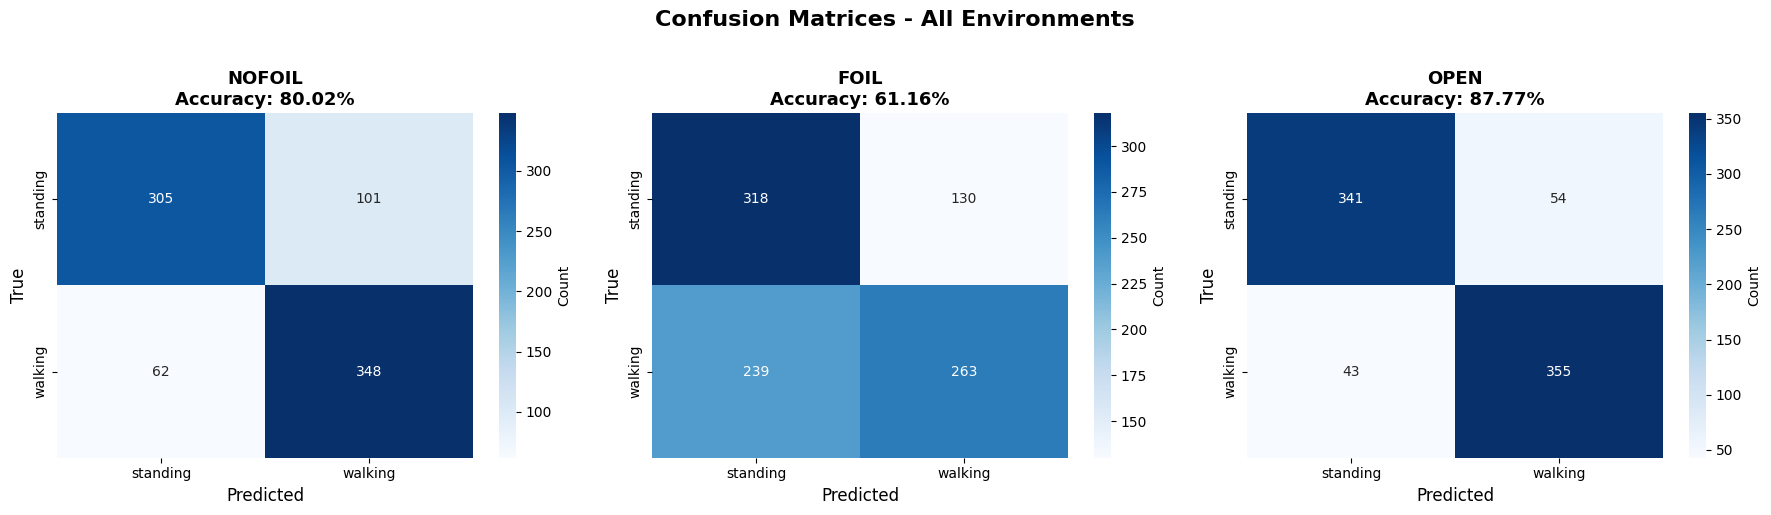

[INFO] Confusion matrices plot saved to 'bfm_all_environments_confusion.png'


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, env in enumerate(ENVIRONMENTS):
    if env not in all_results:
        continue
        
    result = all_results[env]
    cm = result['confusion_matrix']
    le = result['label_encoder']
    acc = result['accuracy']
    
    ax = axes[idx]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
        cbar_kws={'label': 'Count'}
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(f'{env.upper()}\nAccuracy: {acc:.2%}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices - All Environments', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bfm_all_environments_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("[INFO] Confusion matrices plot saved to 'bfm_all_environments_confusion.png'")

## 8. Accuracy Comparison Bar Chart

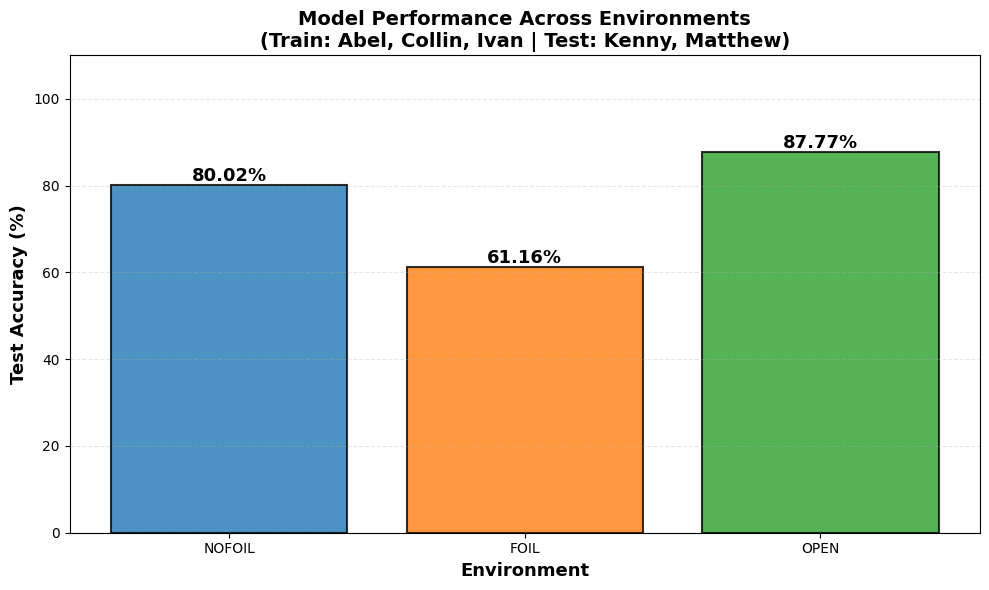

[INFO] Accuracy comparison chart saved to 'bfm_environment_accuracy_comparison.png'


In [9]:
# Extract accuracies
envs = []
accs = []
for env in ENVIRONMENTS:
    if env in all_results:
        envs.append(env.upper())
        accs.append(all_results[env]['accuracy'] * 100)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'][:len(envs)]
bars = plt.bar(envs, accs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.xlabel('Environment', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('Model Performance Across Environments\n(Train: Abel, Collin, Ivan | Test: Kenny, Matthew)',
          fontsize=14, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('bfm_environment_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("[INFO] Accuracy comparison chart saved to 'bfm_environment_accuracy_comparison.png'")

## 9. Save Detailed Reports

In [10]:
# Save individual reports for each environment
for env in ENVIRONMENTS:
    if env not in all_results:
        continue
        
    result = all_results[env]
    le = result['label_encoder']
    
    report_text = classification_report(
        result['y_true'],
        result['y_pred'],
        target_names=le.classes_,
        digits=4
    )
    
    filename = f'bfm_classification_report_{env}.txt'
    with open(filename, 'w') as f:
        f.write(f"BFM Model Classification Report - {env.upper()} Environment\n")
        f.write("="*70 + "\n\n")
        f.write("Configuration:\n")
        f.write(f"  Environment: {env}\n")
        f.write(f"  Train Subjects: {', '.join(TRAIN_SUBJECTS)}\n")
        f.write(f"  Test Subjects: {', '.join(TEST_SUBJECTS)}\n")
        f.write(f"  Window Size: {WINDOW_SIZE}\n")
        f.write(f"  PCA Components: {PCA_COMPONENTS}\n\n")
        f.write(f"Test Accuracy: {result['accuracy']:.4f}\n")
        f.write(f"Test Loss: {result['loss']:.4f}\n\n")
        f.write(report_text)
    
    print(f"[INFO] Saved report: {filename}")

# Save combined summary
with open('bfm_all_environments_summary.txt', 'w') as f:
    f.write("BFM Model Training - All Environments Summary\n")
    f.write("="*70 + "\n\n")
    f.write(f"Train Subjects: {', '.join(TRAIN_SUBJECTS)}\n")
    f.write(f"Test Subjects: {', '.join(TEST_SUBJECTS)}\n\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\n")
    
    for env in ENVIRONMENTS:
        if env in all_results:
            f.write(f"\n{env.upper()}:\n")
            f.write("-" * 40 + "\n")
            f.write(f"  Accuracy: {all_results[env]['accuracy']:.4f}\n")
            f.write(f"  Loss: {all_results[env]['loss']:.4f}\n")

print("\n[INFO] Saved combined summary: bfm_all_environments_summary.txt")
print("\n" + "="*80)
print("ALL REPORTS AND VISUALIZATIONS SAVED")
print("="*80)

[INFO] Saved report: bfm_classification_report_nofoil.txt
[INFO] Saved report: bfm_classification_report_foil.txt
[INFO] Saved report: bfm_classification_report_open.txt

[INFO] Saved combined summary: bfm_all_environments_summary.txt

ALL REPORTS AND VISUALIZATIONS SAVED
